### Here we filter (and analyse?) the geoplant dataset

We would like to then use this dataset to test the models predictions 

In [3]:
#PO Data
import pandas as pd

po_path = "embeddings_data_and_dictionaries/geoplant/PO_metadata_train.csv"

po_data= pd.read_csv(po_path)
po_data.columns


Index(['publisher', 'year', 'month', 'day', 'lat', 'lon', 'geoUncertaintyInM',
       'taxonRank', 'date', 'dayOfYear', 'speciesId', 'surveyId', 'region',
       'county', 'district'],
      dtype='object')

region
ATLANTIC         1670751
CONTINENTAL      1516041
MEDITERRANEAN     690590
ALPINE            566090
BOREAL            499637
PANNONIAN          27254
BLACK SEA           1189
ARCTIC               780
STEPPIC              465
OUTSIDE                1
Name: count, dtype: int64

### Information about the iNaturalist dataset



In [ ]:
import pandas as pd

with open("embeddings_data_and_dictionaries/data_inaturalist/occurrence.txt") as f:
    for i, line in enumerate(f, start=1):
        if i == 2:  # first data row
            print(len(line.rstrip("\n").split("\t")))
            break

occurences=pd.read_csv("embeddings_data_and_dictionaries/data_inaturalist/occurrence.txt", sep="\t", on_bad_lines='skip', nrows=0)
col_list=list(occurences.columns)
#print(col_list)
print(col_list[98])


230
['gbifID', 'accessRights', 'bibliographicCitation', 'language', 'license', 'modified', 'publisher', 'references', 'rightsHolder', 'type', 'institutionID', 'collectionID', 'datasetID', 'institutionCode', 'collectionCode', 'datasetName', 'ownerInstitutionCode', 'basisOfRecord', 'informationWithheld', 'dataGeneralizations', 'dynamicProperties', 'occurrenceID', 'catalogNumber', 'recordNumber', 'recordedBy', 'recordedByID', 'individualCount', 'organismQuantity', 'organismQuantityType', 'sex', 'lifeStage', 'reproductiveCondition', 'caste', 'behavior', 'vitality', 'establishmentMeans', 'degreeOfEstablishment', 'pathway', 'georeferenceVerificationStatus', 'occurrenceStatus', 'preparations', 'disposition', 'associatedOccurrences', 'associatedReferences', 'associatedSequences', 'associatedTaxa', 'otherCatalogNumbers', 'occurrenceRemarks', 'organismID', 'organismName', 'organismScope', 'associatedOrganisms', 'previousIdentifications', 'organismRemarks', 'materialEntityID', 'materialEntityRema

### Code for the interpretation of the results

In [1]:
# import pandas as pd
# import matplotlib.pyplot as plt
# pd.set_option("display.expand_frame_repr", False)
# #Get a clean run_name:
# df=pd.read_csv("results_geoplant.csv")
# df["run_name_clean"] = df["run_name"].str.replace(
#     r"_(mushrooms|plants|arthropods).*",
#     "",
#     regex=True
# )

# df.to_csv("results_geoplant_clean.csv", index=False)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df=pd.read_csv("results/results_geoplant_clean.csv")

#For wich ones linear model does worse? 
small_PR = df[df["auc_emb_PR"] < df["auc_emb_MLP"]]
print(small_PR["run_name"].tolist())
print(small_PR.value_counts("model_name"))

['sweep_classifier_species_name_arthropods_vectors_bioclip_drop_high_freq_False', 'sweep_classifier_species_name_mushrooms_vectors_bioclip_drop_high_freq_True', 'sweep_classifier_species_name_plants_vectors_bioclip_drop_high_freq_True', 'sweep_classifier_species_name_mushrooms_vectors_dino_drop_high_freq_False', 'sweep_classifier_species_name_plants_vectors_dino_drop_high_freq_True', 'sweep_classifier_species_name_arthropods_vectors_dino_drop_high_freq_False', 'sweep_classifier_species_name_plants_vectors_bioclip_drop_high_freq_False', 'sweep_classifier_species_name_plants_vectors_dino_drop_high_freq_False', 'sweep_classifier_species_name_mushrooms_vectors_bioclip_drop_high_freq_False', 'sweep_classifier_species_name_mushrooms_vectors_dino_drop_high_freq_True', 'classifier_emb_target_plants_vectors_bioclip_drop_high_freq_True', 'classifier_emb_target_mushrooms_vectors_dino_drop_high_freq_False', 'classifier_emb_target_mushrooms_vectors_bioclip_drop_high_freq_False', 'classifier_emb_tar

20 out of 24 classifier, 0 for contrastive.
Contrastive succeeds at "making the space linear" in that sense

best PR: 0.7742252453765036 sweep_contrastive_species_emb_plants_drop_high_freq_False
best MLP: 0.7117415099259637 sweep_contrastive_species_emb_plants_drop_high_freq_False
best PR: 0.7609509437767947 sweep_contrastive_species_emb_arthropods_drop_high_freq_True
best MLP: 0.7609509437767947 sweep_contrastive_species_emb_arthropods_drop_high_freq_True
best PR: 0.7558703123167569 contrastive_images_mushrooms_vectors_bioclip_drop_high_freq_True
best MLP: 0.7117415099259637 contrastive_images_mushrooms_vectors_bioclip_drop_high_freq_True
                                             run_name drop_high_freq  \
41  sweep_contrastive_species_emb_arthropods_drop_...           True   
30  contrastive_images_mushrooms_vectors_bioclip_d...           True   
38  sweep_contrastive_species_emb_arthropods_drop_...          False   
36  sweep_contrastive_species_emb_mushrooms_drop_h...           True   
33  contrastive_images_mushrooms_vectors_dino_drop...           True   
34  contrastive_images_arthro

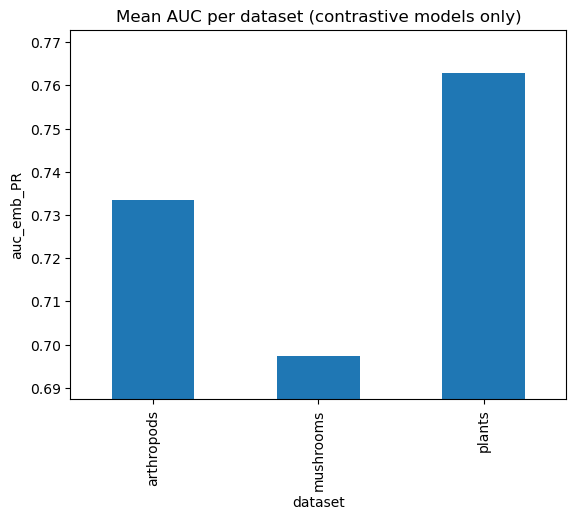

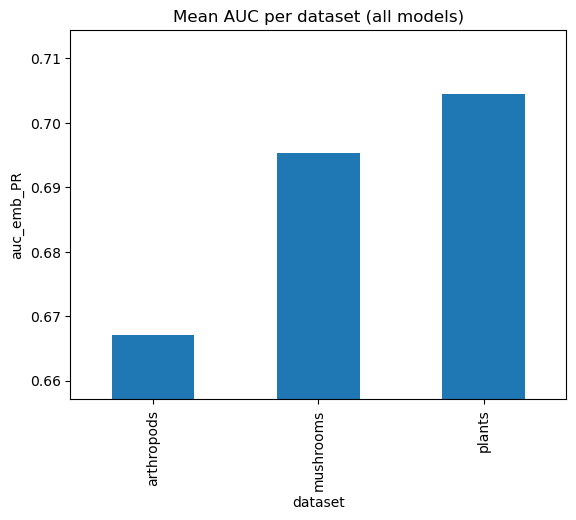

In [6]:
from pd_utils import *
get_highest(df) #so plants
get_highest(df[df["dataset"]=="arthropods"])
get_highest(df[df["dataset"]=="mushrooms"])


test=df[df["dataset"]!="plants"]
print(test.sort_values(by="auc_emb_PR", ascending= False))



#dataset
filtered=df[df["model_name"]=="contrastive"]
filtered=filtered[filtered["drop_high_freq"]==False]
quick_plot( filtered,"dataset","auc_emb_PR","bar",title="Mean AUC per dataset (contrastive models only)",mean=True)
quick_plot(df, "dataset","auc_emb_PR","bar",title="Mean AUC per dataset (all models)",mean=True)


In [13]:
#Specific variable on contrastive:
#quick_plot( df,"run_name_clean","auc_emb_PR","bar")


filtered=df[df["model_name"]=="contrastive"]
print(get_fct( "drop_high_freq","auc_emb_PR",filtered,mean=True))
print(get_fct( "vectors_name","auc_emb_PR",filtered,mean=True))
print(get_fct( "use_species","auc_emb_PR",filtered,mean=True) )

# quick_plot( filtered,"drop_high_freq","auc_emb_PR","bar")
# quick_plot( filtered,"vectors_name","auc_emb_PR","bar")
# quick_plot( filtered,"use_species","auc_emb_PR","bar")


drop_high_freq
False    0.731209
True     0.751119
Name: auc_emb_PR, dtype: float64
vectors_name
vectors            0.756180
vectors_bioclip    0.742215
vectors_dino       0.725097
Name: auc_emb_PR, dtype: float64
use_species
False    0.733656
True     0.756180
Name: auc_emb_PR, dtype: float64


In [16]:
# filtered=quick_filter(df,
#                       show_alpha_earth=True,
#                       drop_high_freq=True,
#                       dataset="plants", #"arthropods",
#                       vectors_name="vectors_bioclip",#["vectors_bioclip","vectors"],
#                       model_name="contrastive",
#                       use_species=None, #always None
#                       run_name_clean=None
#                       )
# quick_plot(df, ["dataset","run_name_clean"],kind="bar", title="Classfifier/Contrastive on all datasets")
# print(filtered)

For the filters 
drop_high_freq=True Or False,
model_name="contrastive", The performance on AUC is species > bioclip >dino for plants and arthropods.
The mushroom,drop_high_freq=True case is "won" by bioclip, by 0.01 auc (0.756). It might be underfitted? (A:No)



In [17]:
#Which high_freq > low_freq
filtered=quick_filter(df,
                      show_alpha_earth=False,
                      drop_high_freq=None,
                      dataset=None, #"arthropods",
                      vectors_name=None,#["vectors_bioclip","vectors"],
                      model_name="contrastive",
                      use_species=None
                      )
pivot = filtered.pivot_table(
    index="run_name_clean",
    columns="drop_high_freq",
    values="auc_emb_PR",
    aggfunc="mean"
)

# Keep only models where False < True
better_with_drop = pivot[(pivot[False] < pivot[True])]

# Print results
print("Models where auc_emb_PR improves when drop_high_freq=True:\n")
print(better_with_drop)

# If you only want the run_name list:
print("\nRun names only:")
print(list(better_with_drop.index))

#full rows
improving_runs = better_with_drop.index

detailed_rows = df[df["run_name_clean"].isin(improving_runs)]

print(detailed_rows.sort_values(["run_name_clean", "drop_high_freq"])) #ALL of them perform better with low frequency


Models where auc_emb_PR improves when drop_high_freq=True:

drop_high_freq                    False     True 
run_name_clean                                   
contrastive_images             0.720034  0.747278
sweep_contrastive_species_emb  0.753559  0.758801

Run names only:
['contrastive_images', 'sweep_contrastive_species_emb']
                                             run_name drop_high_freq  \
24  contrastive_images_arthropods_vectors_bioclip_...          False   
25  contrastive_images_mushrooms_vectors_bioclip_d...          False   
27  contrastive_images_arthropods_vectors_dino_dro...          False   
28  contrastive_images_plants_vectors_dino_drop_hi...          False   
29  contrastive_images_plants_vectors_bioclip_drop...          False   
31  contrastive_images_mushrooms_vectors_dino_drop...          False   
26  contrastive_images_plants_vectors_bioclip_drop...           True   
30  contrastive_images_mushrooms_vectors_bioclip_d...           True   
32  contrastive_ima

Max was taken over multiple values for these groups:
vectors_name
vectors            2
vectors_bioclip    2
vectors_dino       2
Name: auc_emb_PR, dtype: int64


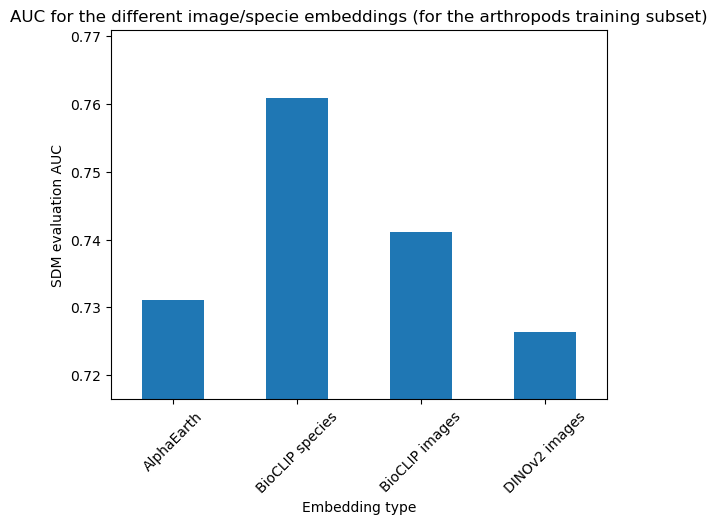

Max was taken over multiple values for these groups:
vectors_name
vectors            2
vectors_bioclip    2
vectors_dino       2
Name: auc_emb_PR, dtype: int64


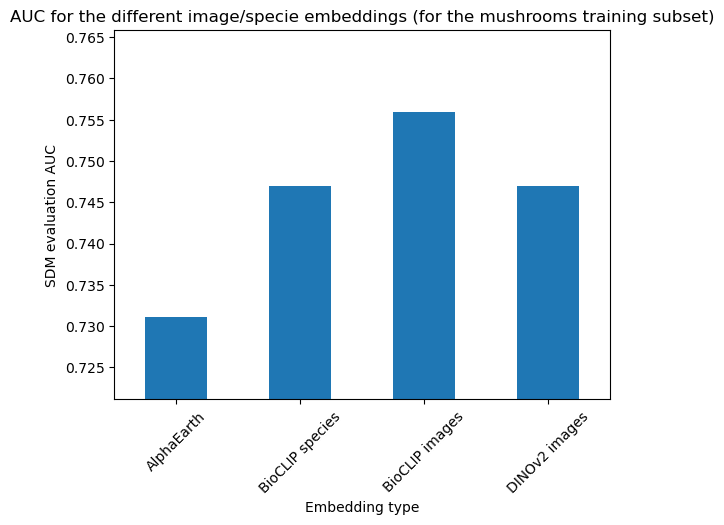

Max was taken over multiple values for these groups:
vectors_name
vectors            2
vectors_bioclip    2
vectors_dino       2
Name: auc_emb_PR, dtype: int64


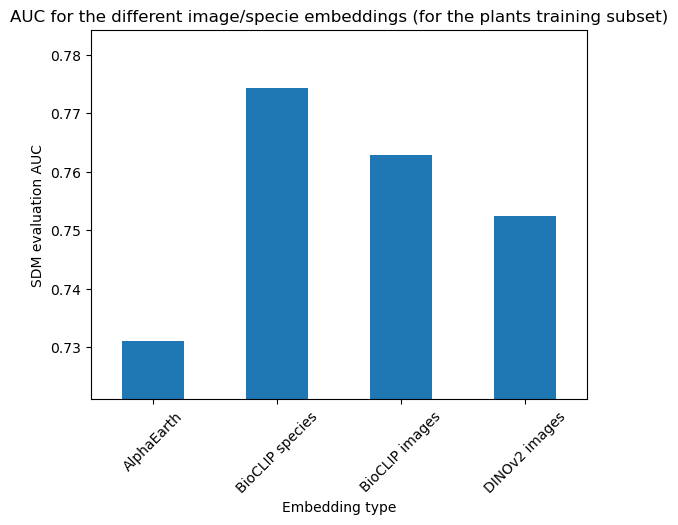

Max was taken over multiple values for these groups:
dataset
arthropods    2
mushrooms     2
plants        2
Name: auc_emb_PR, dtype: int64


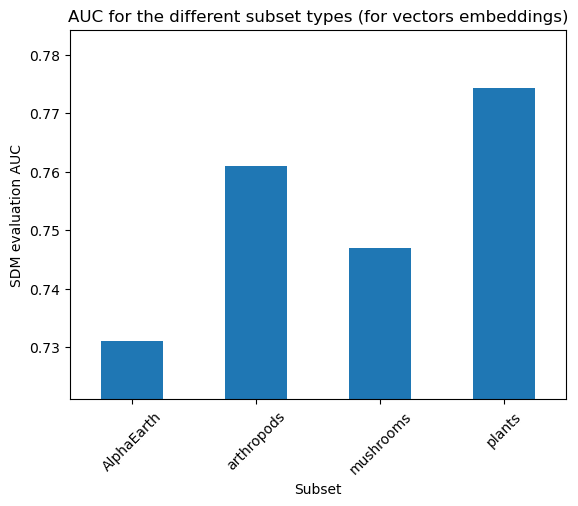

Max was taken over multiple values for these groups:
dataset
arthropods    2
mushrooms     2
plants        2
Name: auc_emb_PR, dtype: int64


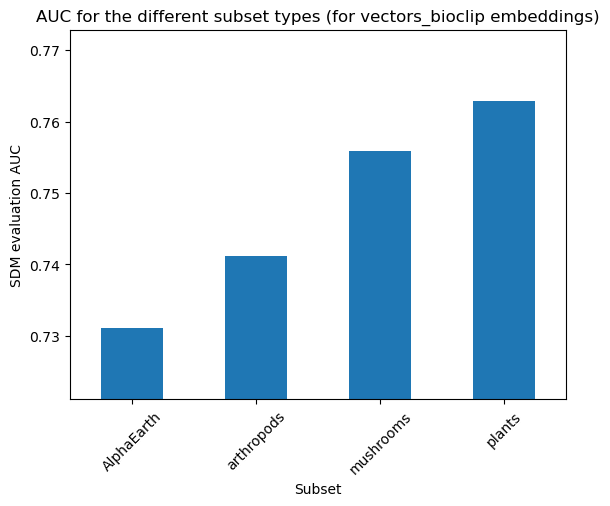

Max was taken over multiple values for these groups:
dataset
arthropods    2
mushrooms     2
plants        2
Name: auc_emb_PR, dtype: int64


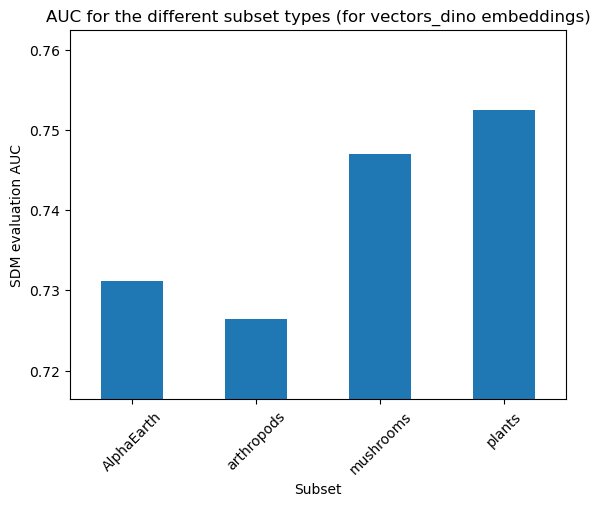

Max was taken over multiple values for these groups:
dataset     vectors_name   
arthropods  vectors            2
            vectors_bioclip    2
            vectors_dino       2
mushrooms   vectors            2
            vectors_bioclip    2
            vectors_dino       2
plants      vectors            2
            vectors_bioclip    2
            vectors_dino       2
Name: auc_emb_PR, dtype: int64


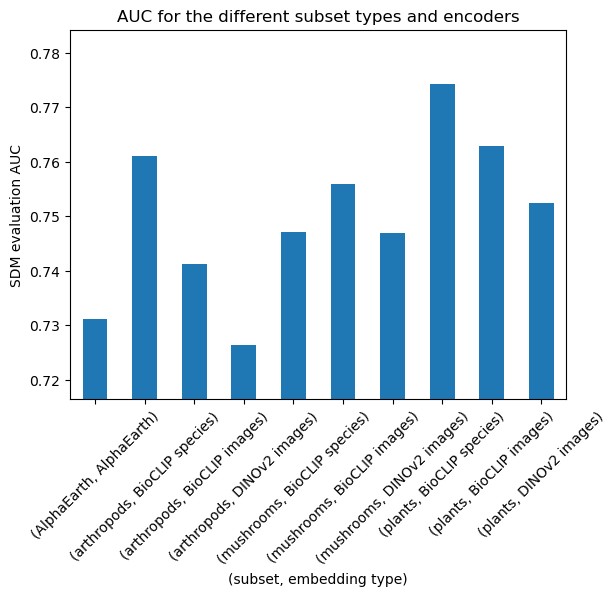

In [12]:
from pd_utils import *
for subset in ["arthropods", "mushrooms", "plants"]:
    filtered=quick_filter(df,
                        show_alpha_earth=True,
                        drop_high_freq=None,
                        dataset=subset, #"arthropods",
                        vectors_name=None,#["vectors_bioclip","vectors"],
                        model_name="contrastive",
                        use_species=None
                        )

    quick_plot(filtered, "vectors_name", title=f"AUC for the different image/specie embeddings (for the {subset} training subset)",xlabel="Embedding type",ylabel="SDM evaluation AUC",
               rename_index={"vectors_bioclip": "BioCLIP images",
                             "vectors": "BioCLIP species",
                             "vectors_dino": "DINOv2 images",
                             "alpha_earth": "AlphaEarth"
                             },
                multiple_values_handling="max",
               )
    
for vector_name in ["vectors", "vectors_bioclip", "vectors_dino"]:
    filtered=quick_filter(df,
                        show_alpha_earth=True,
                        drop_high_freq=None,
                        dataset=None, #"arthropods",
                        vectors_name=vector_name,#["vectors_bioclip","vectors"],
                        model_name="contrastive",
                        use_species=None
                        )

    quick_plot(filtered, "dataset", title=f"AUC for the different subset types (for {vector_name} embeddings)",xlabel="Subset",ylabel="SDM evaluation AUC",
               rename_index={"vectors_bioclip": "BioCLIP images",
                             "vectors": "BioCLIP species",
                             "vectors_dino": "DINOv2 images",
                             "alpha_earth": "AlphaEarth"
                             },
                multiple_values_handling="max",
               )
    
filtered=quick_filter(df,
                        show_alpha_earth=True,
                        drop_high_freq=None,
                        dataset=None, #"arthropods",
                        vectors_name=None,#["vectors_bioclip","vectors"],
                        model_name="contrastive",
                        use_species=None
                        )
quick_plot(filtered, ["dataset","vectors_name"], title=f"AUC for the different subset types and encoders",xlabel="(subset, embedding type)",ylabel="SDM evaluation AUC",
        rename_index={"vectors_bioclip": "BioCLIP images",
                        "vectors": "BioCLIP species",
                        "vectors_dino": "DINOv2 images",
                        "alpha_earth": "AlphaEarth"
                        },
        multiple_values_handling="max",
        )